# Gaussian Mixtures and the EM Algorithm

In this notebook, we implement the EM algorithm in the one-dimensional case. 

Rather than add complexity by treating $K$, the number of components in the Gaussian mixture, as a hyperparameter, we will just work with the knowledge that $K=3$.

## Generating data

The first step is to generate some data. We create 30 data points from the mixture $0.25\mathcal{N}(-5,4) + 0.25\mathcal{N}(0,4) + 0.5\mathcal{N}(10,4)$ 

(Note: to be clear, the second entry in each $\mathcal{N}(-,-)$ denotes the variance.)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

In [6]:
mixture_weights = [0.25,0.25,0.5]
mixture_means = [-5,0,10]
mixture_variances = [4,4,4]

data_points = []

for rand in np.random.random(30):
    component = 0 if rand < mixture_weights[0] else (1 if rand < (mixture_weights[0]+mixture_weights[1]) else 2)
    data_point = np.random.normal(loc=mixture_means[component], scale=np.sqrt(mixture_variances[component]))
    data_points.append(data_point)

We now forget that we know `mixture_{weights,means,variances}`. We now try to recover them as best we can using the EM algorithm. 

First, let's plot the 30 generated data points.

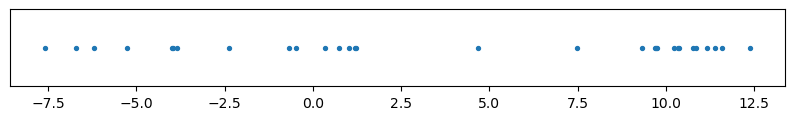

In [45]:
plt.figure(figsize=(10,1))
plt.scatter(data_points,np.zeros(30),s=8)
plt.yticks([])
plt.show()

## Initial parameter guess

With the assumption that $K=3$, let us start with the following initial guess:

$$0.34\mathcal{N}(-3,1) + 0.33\mathcal{N}(-1,1) + 0.33\mathcal{N}(7.5,5)$$ 

We start by plotting this mixture alongside our data points.

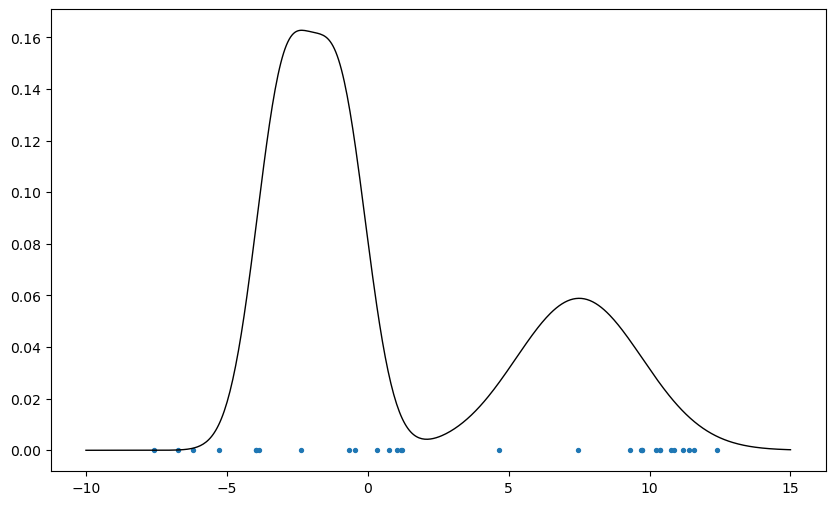

In [11]:
initial_weights = [0.34,0.33,0.33]
initial_means = [-3,-1,7.5]
initial_variances = [1,1,5]
initial_parameters = [initial_weights,initial_means,initial_variances]

x_vals = np.linspace(-10, 15, 500)

initial_mixture_pdf = np.zeros(len(x_vals))

for weight, mean, variance in zip(*initial_parameters):
    initial_mixture_pdf += weight * norm.pdf(x_vals, loc=mean, scale=np.sqrt(variance))

plt.figure(figsize=(10,6))
plt.plot(x_vals, initial_mixture_pdf, color='black', linewidth=1)
plt.scatter(data_points,np.zeros(30),s=8)
plt.show()

## Responsibilities

To update the means, variances and weights, we require the responsibility matrix $R \in M_{k \times n}(\mathbb{R})$, for us, $(k,n) = (3,30)$ (we write the matrix "landscape" for display reasons).

Entry $(k,n)$ of this matrix, denoted $r_{k,n}$, is given by 
$$\displaystyle r_{k,n} := \frac{\pi_k\mathcal{N}(x_n | \mu_k, \sigma^2_k)}{\sum_{j=1}^3 \pi_j\mathcal{N}(x_n | \mu_j, \sigma^2_j)},$$
where $x_n$ is the $n^{th}$ data point (we have $30$ data points), and $(\pi_k, \mu_k, \sigma^2_k)$ is the weight, mean and variance of the $k^{th}$ component, respectively (we have $3$ components).

### What is $r_{k,n}$ telling us?

The value $0 \leq r_{k,n} \leq 1$ is the probability that the data point $x_n \in \mathbb{R}$ came from the $k^{th}$ mixture component. 

To see this visually, suppose the value of the mixture's density function, $g$, at point $x_n$ is broken into its values at $x_n$ from each (weighted) mixture component as follows:

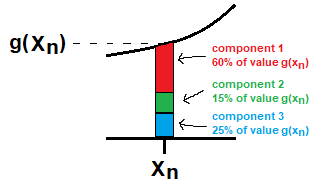

Then, $r_{1,n} = 0.6$, $r_{2,n} = 0.15$, and $r_{3,n} = 0.25$.

For example, if the value $x_n$ is observed, there is a $60\%$ chance that Component 1 was responsible for producing it.

Indeed, $p(\text{Component 1} | x_n) = \frac{p(\text{Component 1}, x_n)}{p(x_n)} = \frac{\pi_1\mathcal{N}(x_n | \mu_1, \sigma^2_1)}{\sum_{j=1}^3 \pi_j\mathcal{N}(x_n | \mu_j, \sigma^2_j)} = r_{1,n}$

### Calculating the responsibility matrix

We now calculate the responsibilities matrix ($3 \times 30$) using our initial parameters. 

Observe that the columns sum to $1$ (as each value in a particular column is the chance the corresponding data point came from a certain component, and the data point must have come from somewhere, that is, there is a $100\%$ chance it came from one of the components).

In [18]:
def r_kn(xn:float, k:int, parameters: list[list]) -> float:
    """
    Takes a data point xn, a k:int, and parameters = [<list of weights>, <list of means>, <list of variances>] 
    and calculates r_{k,n} = p(component k | x_n).
    """
    weights, means, variances = parameters
    numerator = weights[k]*norm.pdf(xn, loc=means[k], scale=np.sqrt(variances[k]))
    denominator = sum(weight*norm.pdf(xn, loc=mean, scale=np.sqrt(variance)) for weight, mean, variance in zip(*parameters))
    return numerator/denominator

R_matrix = np.array([[round(r_kn(xn,k,initial_parameters),1) for xn in data_points] for k in (0,1,2)])

from tabulate import tabulate
print(tabulate(R_matrix))

-  -  -  -  -  -  -  -  -  ---  -  -  -  -  -  -  -  ---  -  -  -  ---  -  -  ---  ---  -  -  -  -
0  0  0  0  0  0  1  1  1  0    0  0  0  0  0  0  1  0.7  0  0  1  0    1  1  0.1  0    0  0  0  0
0  0  0  1  0  0  0  0  0  0.9  0  0  0  1  0  1  0  0.3  0  0  0  0.9  0  0  0.9  0.9  0  0  0  0
1  1  1  0  1  1  0  0  0  0.1  1  1  1  0  1  0  0  0    1  1  0  0.1  0  0  0    0.1  1  1  1  1
-  -  -  -  -  -  -  -  -  ---  -  -  -  -  -  -  -  ---  -  -  -  ---  -  -  ---  ---  -  -  -  -


## The EM algorithm

### Updating the parameters

The parameters are updated using the following formulae, where $N_k := \sum_{n=1}^N r_{k,n}$ is the sum of the responsibilities of the $k^{th}$ component over all data points (for us, $N=30$).

$$\mu_k^{\text{new}} = \frac{1}{N_k}\sum_{n=1}^{30} r_{k,n}x_n $$

$$\sigma_k^2{}^\text{new} =  \frac{1}{N_k}\sum_{n=1}^{30}r_{k,n}(x_n-\mu_k^\text{new})^2$$

$$\pi_k^\text{new} = \frac{N_k}{30}$$

In words, $\mu_k^{\text{new}}$ is just an average of the data points, weighted by the responsibilities at each point.

The new variance, $\sigma_k^2{}^\text{new}$, is the sample variance formula, weighted by the responsibilities at each point and making use of the newly updated mean.

Finally, the updated weight, $\pi_k^\text{new}$, is just the average responsibility over all data points.

In [21]:
def update_mean(R_mat, data_points):
    """
    Takes a responsibility matrix, R_mat, and the data points, and updates the means.
    Return is a list of the form [new_mu_1, new_mu_2, new_mu_3].
    """
    three_updated_means = []
    for responsibility_row in R_mat:
        Nk = sum(responsibility_row)
        new_mu = 1/Nk * sum(resp*data_pt for (resp,data_pt) in zip(responsibility_row, data_points))
        three_updated_means.append(new_mu)
    return three_updated_means

def update_variance(R_mat, data_points, means):
    """    
    Takes a responsibility matrix, R_mat, the data points, and the three means, and updates the variance.
    Return is a list of the form [new_variance_1, new_variance_1, new_variance_1].
    """    
    three_updated_variances = []
    for responsibility_row,mean in zip(R_mat,means):
        Nk = sum(responsibility_row)
        new_variance = 1/Nk * sum(resp*(data_pt-mean)**2 for (resp,data_pt) in zip(responsibility_row, data_points))
        three_updated_variances.append(new_variance)
    return three_updated_variances

def update_weights(R_mat):
    """
    Takes a responsibility matrix, R_mat, and updates the weights for the components of the GMM.
    """
    N = np.sum(R_mat)
    Nks = np.sum(R_mat,axis=1)
    return [sum_of_row/N for sum_of_row in Nks]    

updated_means = update_mean(R_matrix, data_points)
updated_variances = update_variance(R_matrix, data_points, updated_means)
updated_weights = update_weights(R_matrix)

Let's plot the Gaussian mixture with updated parameters alongside both the data points and the Gaussian mixture with the initial parameters to visually compare.

(Recall we have `x_vals` and `initial_mixture_pdf` already defined.)

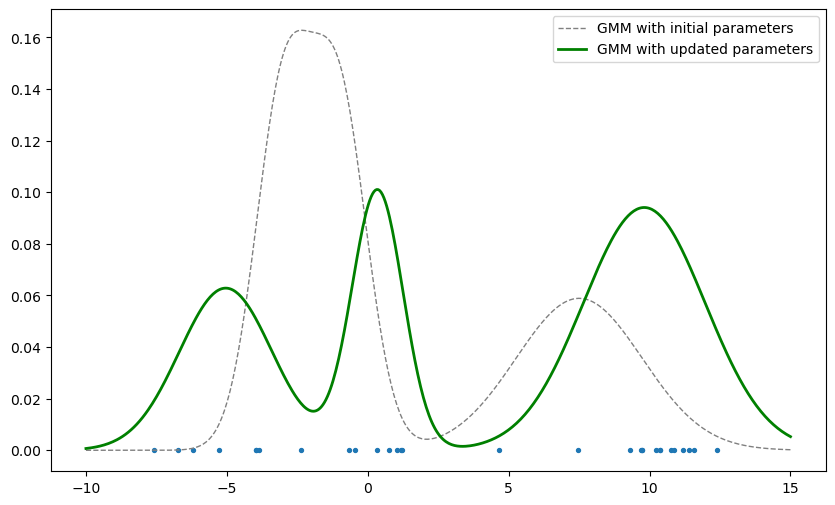

In [23]:
#Recall: x_vals = np.linspace(-10, 15, 500)

updated_mixture_pdf = np.zeros(len(x_vals))

for weight, mean, variance in zip(updated_weights, updated_means, updated_variances):
    updated_mixture_pdf += weight * norm.pdf(x_vals, loc=mean, scale=np.sqrt(variance))

plt.figure(figsize=(10,6))
plt.plot(x_vals, initial_mixture_pdf, color='gray', linewidth=1, linestyle="--", label = "GMM with initial parameters")
plt.plot(x_vals, updated_mixture_pdf, color='green', linewidth=2, label = "GMM with updated parameters")
plt.scatter(data_points,np.zeros(30),s=8)
plt.legend()
plt.show()

The final question to address is, "When do we stop iterating?"

To answer this, we introduce the log likelihood function, which for a (mixed Gaussian) pdf, $g$, is given by:

$$ \mathcal{L}(g) = \sum_{i=1}^{30} \log(g(x_i))$$

We know that iterating our parameters will lead to the log likelihood reaching a local maximum. So, in short, we keep iterating until the log likelihood stabilises.

In [25]:
def log_likelihood(data_points:list, parameters:list[list]):
    """
    Takes a list of (30) data points, and a list of parameters = [<weights>, <means>, <variances>] 
    and calculates the log likelihood
    """
    log_likelihood = 0
    for xn in data_points:
        log_likelihood += np.log(sum(weight * norm.pdf(xn, loc=mean, scale=np.sqrt(variance)) 
                                     for weight, mean, variance in zip(*parameters)))
    return log_likelihood

iteration_of_parameters_data = {"Component 1":[], "Component 2": [], "Component 3": [], "Log Likelihood": []}

# add initial parameters to the data dictionary
for component, weight, mean, variance in zip(iteration_of_parameters_data, *initial_parameters):
    iteration_of_parameters_data[component].append([weight, mean, variance])
iteration_of_parameters_data["Log Likelihood"].append(log_likelihood(data_points, initial_parameters))
                                                      
# add updated parameters to the data dictionary
updated_parameters = [updated_weights, updated_means, updated_variances]
for component, weight, mean, variance in zip(iteration_of_parameters_data, *updated_parameters):
    iteration_of_parameters_data[component].append([weight, mean, variance])
iteration_of_parameters_data["Log Likelihood"].append(log_likelihood(data_points, updated_parameters))

In [26]:
while abs(iteration_of_parameters_data["Log Likelihood"][-1] - iteration_of_parameters_data["Log Likelihood"][-2]) > 10**(-3):
    current_component_1_parameters, current_component_2_parameters, current_component_3_parameters \
                = [iteration_of_parameters_data[comp][-1] for comp in ["Component 1", "Component 2", "Component 3"]]
    current_weights, current_means, current_variances = zip(current_component_1_parameters, 
                                                            current_component_2_parameters, current_component_3_parameters)
    current_parameters = [current_weights, current_means, current_variances]

    new_R_matrix = np.array([[round(r_kn(xn,k,current_parameters),1) for xn in data_points] for k in (0,1,2)])
    
    new_means = update_mean(new_R_matrix, data_points)
    new_variances = update_variance(new_R_matrix, data_points, new_means)
    new_weights = update_weights(new_R_matrix)

    #add these new parameters to the data dictionary
    new_parameters = [new_weights, new_means, new_variances]
    for component, weight, mean, variance in zip(iteration_of_parameters_data, *new_parameters):
        iteration_of_parameters_data[component].append([weight, mean, variance])
    iteration_of_parameters_data["Log Likelihood"].append(log_likelihood(data_points, new_parameters))

In [27]:
iteration_of_parameters_df = pd.DataFrame.from_dict(data=iteration_of_parameters_data)
iteration_of_parameters_df.columns = ["Component 1 (weight, mean, variance)", 
                                      "Component 2 (weight, mean, variance)", 
                                      "Component 3 (weight, mean, variance)", 
                                      "Log Likelihood evaluation"]
iteration_of_parameters_df

,"Component 1 (weight, mean, variance)","Component 2 (weight, mean, variance)","Component 3 (weight, mean, variance)",Log Likelihood evaluation
0,"[0.34, -3, 1]","[0.33, -1, 1]","[0.33, 7.5, 5]",-122.071620
1,"[0.26, -5.0396793336781345, 2.7254777215435237]","[0.23, 0.34356973501739796, 0.8295193313038207]","[0.51, 9.80954582852058, 4.677796212395617]",-85.008762
2,"[0.26333333333333336, -5.027473495027979, 2.62...","[0.23666666666666666, 0.4397326063711744, 0.63...","[0.5, 9.982808176718745, 3.240198433327283]",-84.228869
3,"[0.26666666666666666, -4.99431140718365, 2.683...","[0.23333333333333334, 0.479936021711927, 0.525...","[0.5, 9.982808176718745, 3.240198433327283]",-84.148910
4,"[0.26999999999999996, -4.940969227522705, 2.87...","[0.23, 0.4966538604997384, 0.5132034368740226]","[0.5, 9.982808176718745, 3.240198433327283]",-84.129658
5,"[0.26999999999999996, -4.940969227522705, 2.87...","[0.23, 0.4966538604997384, 0.5132034368740226]","[0.5, 9.982808176718745, 3.240198433327283]",-84.129658


The log likelihood has stabilised, meaning we have landed at a local maximum. 

We conclude by plotting the locally optimal parameters alongside the initial guess, the original data points, and the true mixture (which we have pretended we didn't know about).

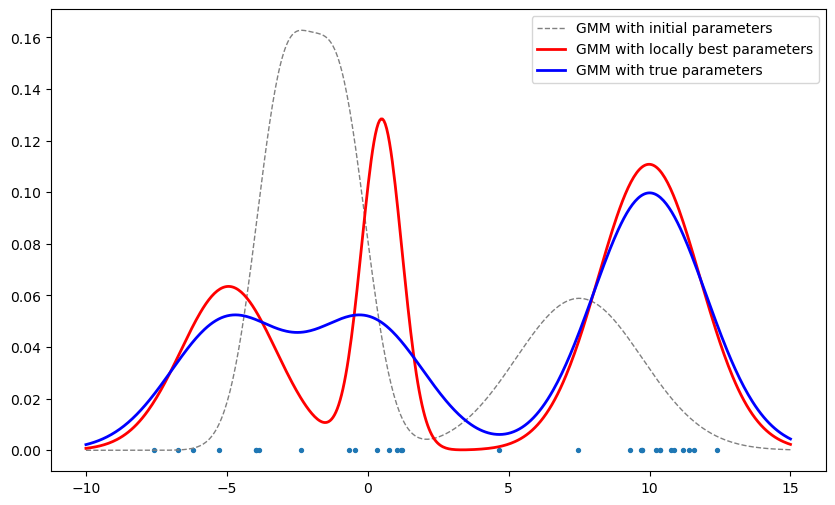

In [29]:
locally_best_mixture_pdf = np.zeros(len(x_vals))
#new_{weights, means, variances} found in the previous while loop are the ones on the bottom row of the above dataframe.
for weight, mean, variance in zip(new_weights, new_means, new_variances):
    locally_best_mixture_pdf += weight * norm.pdf(x_vals, loc=mean, scale=np.sqrt(variance))

true_mixture_pdf = np.zeros(len(x_vals))
for weight, mean, variance in zip(mixture_weights, mixture_means, mixture_variances):
    true_mixture_pdf += weight * norm.pdf(x_vals, loc=mean, scale=np.sqrt(variance))

plt.figure(figsize=(10,6))
plt.plot(x_vals, initial_mixture_pdf, color='gray', linewidth=1, linestyle="--", label = "GMM with initial parameters")
plt.plot(x_vals, locally_best_mixture_pdf, color='red', linewidth=2, label = "GMM with locally best parameters")
plt.plot(x_vals, true_mixture_pdf, color='blue', linewidth=2, label = "GMM with true parameters")
plt.scatter(data_points,np.zeros(30),s=8)
plt.legend()
plt.show()